# ASL Object Detector - Training Notebook
## Faster R-CNN (ResNet50-FPN) for American Sign Language Letter Detection

This notebook covers:
1. Install dependencies & download dataset from Roboflow
2. Data exploration & annotation parsing (Pascal VOC)
3. Data cleaning & filtering (A-Z only)
4. Custom Dataset & DataLoader
5. Faster R-CNN model initialization (27 classes)
6. Training loop with validation
7. Model export

## 1. Install Dependencies & Download Dataset from Roboflow

In [2]:
import os

DATASET_DIR = os.path.join('..', 'data')
print(f"Dataset location: {DATASET_DIR}")
print(f"Splits: {[d for d in os.listdir(DATASET_DIR) if os.path.isdir(os.path.join(DATASET_DIR, d))]}")

Dataset location: ..\data
Splits: ['test', 'train', 'valid']


## 2. Data Exploration and Annotation Parsing

In [3]:
import xml.etree.ElementTree as ET
from collections import Counter


def parse_voc_split(split_dir):
    """Parse all Pascal VOC XML files in a split directory and return records."""
    records = []
    xml_files = [f for f in os.listdir(split_dir) if f.endswith('.xml')]

    for xml_file in xml_files:
        xml_path = os.path.join(split_dir, xml_file)
        tree = ET.parse(xml_path)
        root = tree.getroot()

        filename = root.find('filename').text
        img_path = os.path.join(split_dir, filename)

        if not os.path.exists(img_path):
            continue

        boxes = []
        labels = []
        for obj in root.findall('object'):
            label = obj.find('name').text
            bndbox = obj.find('bndbox')
            xmin = int(bndbox.find('xmin').text)
            ymin = int(bndbox.find('ymin').text)
            xmax = int(bndbox.find('xmax').text)
            ymax = int(bndbox.find('ymax').text)
            boxes.append([xmin, ymin, xmax, ymax])
            labels.append(label)

        records.append({
            'image_path': img_path,
            'boxes': boxes,
            'labels': labels
        })

    return records


# Parse each split
train_records_raw = parse_voc_split(os.path.join(DATASET_DIR, 'train'))
val_records_raw = parse_voc_split(os.path.join(DATASET_DIR, 'valid'))
test_records_raw = parse_voc_split(os.path.join(DATASET_DIR, 'test'))

print(f"Train images: {len(train_records_raw)}")
print(f"Validation images: {len(val_records_raw)}")
print(f"Test images: {len(test_records_raw)}")

# Overall statistics
all_labels = [l for split in [train_records_raw, val_records_raw, test_records_raw]
              for r in split for l in r['labels']]
label_counts = Counter(all_labels)
print(f"\nTotal annotations: {len(all_labels)}")
print(f"Unique classes ({len(label_counts)}): {sorted(label_counts.keys())}")
print(f"\nClass distribution:")
for label, count in sorted(label_counts.items()):
    print(f"  {label}: {count}")

Train images: 504
Validation images: 144
Test images: 72

Total annotations: 720
Unique classes (26): ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z']

Class distribution:
  A: 29
  B: 25
  C: 25
  D: 28
  E: 25
  F: 30
  G: 30
  H: 29
  I: 30
  J: 38
  K: 27
  L: 28
  M: 28
  N: 27
  O: 28
  P: 25
  Q: 26
  R: 25
  S: 30
  T: 25
  U: 25
  V: 28
  W: 27
  X: 26
  Y: 26
  Z: 30


### Visualize Sample Images

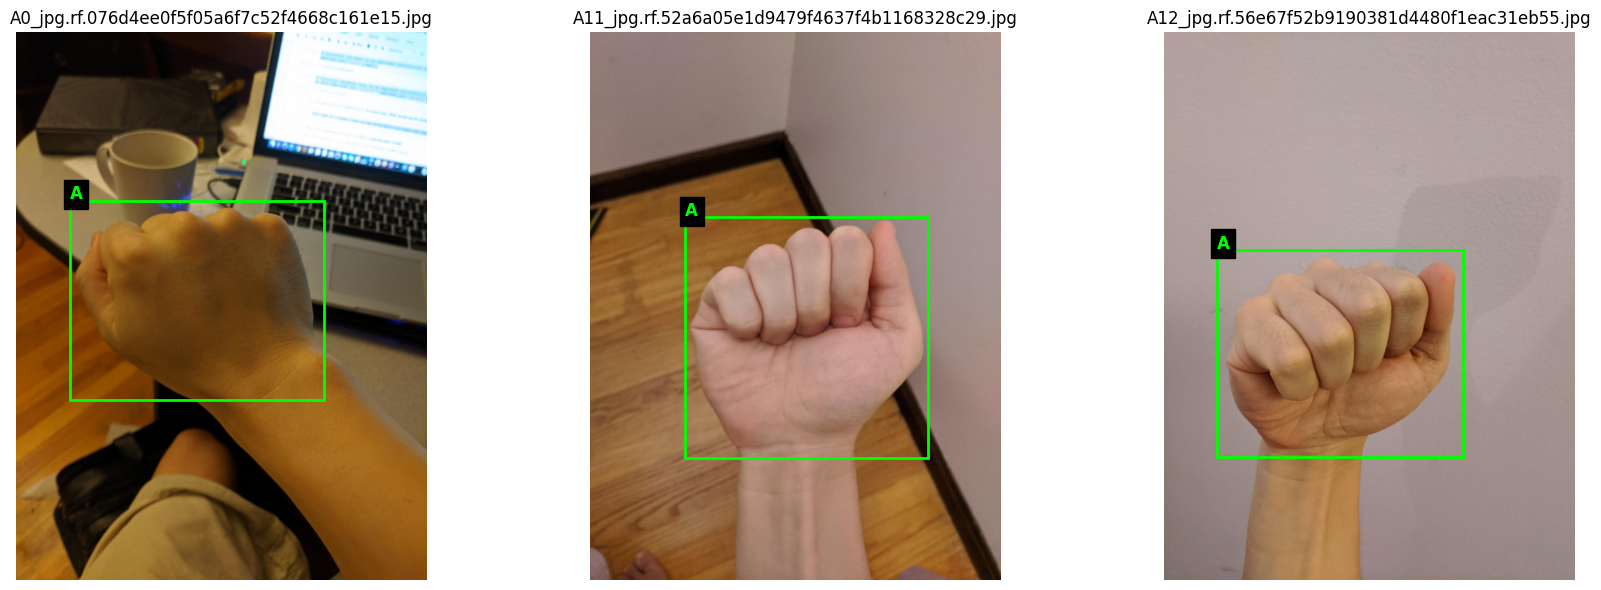

In [4]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
for idx, ax in enumerate(axes):
    if idx >= len(train_records_raw):
        break
    rec = train_records_raw[idx]
    img = Image.open(rec['image_path'])
    ax.imshow(img)
    for box, label in zip(rec['boxes'], rec['labels']):
        xmin, ymin, xmax, ymax = box
        rect = patches.Rectangle((xmin, ymin), xmax - xmin, ymax - ymin,
                                 linewidth=2, edgecolor='lime', facecolor='none')
        ax.add_patch(rect)
        ax.text(xmin, ymin - 5, label, color='lime', fontsize=12,
                fontweight='bold', backgroundcolor='black')
    ax.set_title(os.path.basename(rec['image_path']))
    ax.axis('off')
plt.tight_layout()
plt.show()

## 3. Data Cleaning and Filtering (A-Z Only)

Filter annotations to keep only single uppercase A-Z labels. Discard images with no valid boxes remaining.

In [5]:
import string

VALID_LABELS = set(string.ascii_uppercase)  # A-Z
LABEL_TO_IDX = {letter: idx + 1 for idx, letter in enumerate(string.ascii_uppercase)}  # A=1, B=2, ..., Z=26
IDX_TO_LABEL = {v: k for k, v in LABEL_TO_IDX.items()}

print(f"Label mapping: {LABEL_TO_IDX}")
print(f"Background class = 0")


def filter_records(records):
    """Keep only A-Z labels, discard images with no valid annotations."""
    cleaned = []
    discarded = 0
    for rec in records:
        valid_boxes = []
        valid_labels = []
        for box, label in zip(rec['boxes'], rec['labels']):
            if label in VALID_LABELS:
                valid_boxes.append(box)
                valid_labels.append(label)
        if len(valid_boxes) > 0:
            cleaned.append({
                'image_path': rec['image_path'],
                'boxes': valid_boxes,
                'labels': valid_labels
            })
        else:
            discarded += 1
    return cleaned, discarded


train_records, train_discarded = filter_records(train_records_raw)
val_records, val_discarded = filter_records(val_records_raw)
test_records, test_discarded = filter_records(test_records_raw)

print(f"\n--- After Filtering ---")
print(f"Train: {len(train_records)} images (discarded {train_discarded})")
print(f"Valid: {len(val_records)} images (discarded {val_discarded})")
print(f"Test:  {len(test_records)} images (discarded {test_discarded})")

# Cleaned class distribution
all_cleaned = [l for split in [train_records, val_records, test_records]
               for r in split for l in r['labels']]
print(f"\nTotal valid annotations: {len(all_cleaned)}")
print(f"Classes: {sorted(set(all_cleaned))}")

Label mapping: {'A': 1, 'B': 2, 'C': 3, 'D': 4, 'E': 5, 'F': 6, 'G': 7, 'H': 8, 'I': 9, 'J': 10, 'K': 11, 'L': 12, 'M': 13, 'N': 14, 'O': 15, 'P': 16, 'Q': 17, 'R': 18, 'S': 19, 'T': 20, 'U': 21, 'V': 22, 'W': 23, 'X': 24, 'Y': 25, 'Z': 26}
Background class = 0

--- After Filtering ---
Train: 504 images (discarded 0)
Valid: 144 images (discarded 0)
Test:  72 images (discarded 0)

Total valid annotations: 720
Classes: ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z']


## 4. Custom ASL Dataset Class (Pascal VOC Format)

In [6]:
import torch
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T
import random


class ASLDataset(Dataset):
    def __init__(self, records, label_to_idx, train=False):
        self.records = records
        self.label_to_idx = label_to_idx
        self.train = train
        # Simulates webcam lighting / color variation
        self.color_jitter = T.ColorJitter(brightness=0.4, contrast=0.4, saturation=0.3, hue=0.05)

    def __len__(self):
        return len(self.records)

    def __getitem__(self, idx):
        rec = self.records[idx]
        img = Image.open(rec['image_path']).convert('RGB')

        orig_w, orig_h = img.size
        boxes  = [list(b) for b in rec['boxes']]
        labels = list(rec['labels'])

        # --- Scale jitter: random crop 60-100% then resize to 640 ---
        # Makes the model see hands at smaller relative scales (mimics webcam full-body view)
        if self.train and random.random() < 0.5:
            scale = random.uniform(0.6, 1.0)
            cw = max(1, int(orig_w * scale))
            ch = max(1, int(orig_h * scale))
            left = random.randint(0, orig_w - cw)
            top  = random.randint(0, orig_h - ch)

            new_boxes, new_labels = [], []
            for box, lbl in zip(boxes, labels):
                x1, y1, x2, y2 = box
                x1c = max(0, x1 - left);  y1c = max(0, y1 - top)
                x2c = min(cw, x2 - left); y2c = min(ch, y2 - top)
                if x2c > x1c + 10 and y2c > y1c + 10:
                    new_boxes.append([x1c, y1c, x2c, y2c])
                    new_labels.append(lbl)

            if new_boxes:  # only apply if at least one box survived
                img = img.crop((left, top, left + cw, top + ch))
                orig_w, orig_h = cw, ch
                boxes, labels = new_boxes, new_labels

        # Resize to 640x640
        img = T.functional.resize(img, (640, 640))
        scale_x = 640.0 / orig_w
        scale_y = 640.0 / orig_h

        boxes_t = torch.as_tensor(boxes, dtype=torch.float32)
        boxes_t[:, 0] *= scale_x
        boxes_t[:, 1] *= scale_y
        boxes_t[:, 2] *= scale_x
        boxes_t[:, 3] *= scale_y

        labels_t = torch.as_tensor(
            [self.label_to_idx[l] for l in labels], dtype=torch.int64
        )
        image_id = torch.tensor([idx])
        area = (boxes_t[:, 3] - boxes_t[:, 1]) * (boxes_t[:, 2] - boxes_t[:, 0])
        iscrowd = torch.zeros((len(boxes_t),), dtype=torch.int64)

        target = {
            'boxes': boxes_t,
            'labels': labels_t,
            'image_id': image_id,
            'area': area,
            'iscrowd': iscrowd
        }

        # --- Color jitter (train only, applied as PIL before ToTensor) ---
        if self.train:
            img = self.color_jitter(img)

        # --- Horizontal flip with correct box transform (train only) ---
        if self.train and random.random() > 0.5:
            img = T.functional.hflip(img)
            boxes_flipped = target['boxes'].clone()
            boxes_flipped[:, 0] = 640 - target['boxes'][:, 2]
            boxes_flipped[:, 2] = 640 - target['boxes'][:, 0]
            target['boxes'] = boxes_flipped

        img = T.functional.to_tensor(img)
        return img, target


print("ASLDataset class defined (640x640 resize + scale jitter + color jitter + hflip).")


ASLDataset class defined (640x640 resize + scale jitter + color jitter + hflip).


## 5. DataLoader Setup with Collate Function

In [7]:
def collate_fn(batch):
    return tuple(zip(*batch))

# Instantiate datasets
train_dataset = ASLDataset(train_records, LABEL_TO_IDX, train=True)
val_dataset = ASLDataset(val_records, LABEL_TO_IDX, train=False)

train_loader = DataLoader(
    train_dataset, batch_size=4, shuffle=True,
    num_workers=0, collate_fn=collate_fn, pin_memory=True
)
val_loader = DataLoader(
    val_dataset, batch_size=4, shuffle=False,
    num_workers=0, collate_fn=collate_fn, pin_memory=True
)

# Verify DataLoader
images, targets = next(iter(train_loader))
print(f"Batch size: {len(images)}")
print(f"Image tensor shape: {images[0].shape}")
print(f"Target keys: {targets[0].keys()}")
print(f"Number of boxes in first image: {targets[0]['boxes'].shape[0]}")
print(f"Labels in first image: {targets[0]['labels']}")

Batch size: 4
Image tensor shape: torch.Size([3, 640, 640])
Target keys: dict_keys(['boxes', 'labels', 'image_id', 'area', 'iscrowd'])
Number of boxes in first image: 1
Labels in first image: tensor([14])


## 6. Faster R-CNN Model Initialization (27 Classes)

27 classes = 26 ASL letters (A-Z) + 1 background class (index 0)

In [8]:
import torchvision
from torchvision.models.detection import fasterrcnn_resnet50_fpn, FasterRCNN_ResNet50_FPN_Weights
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor

NUM_CLASSES = 27  # 26 letters + background

# Load pretrained Faster R-CNN
model = fasterrcnn_resnet50_fpn(weights=FasterRCNN_ResNet50_FPN_Weights.DEFAULT)

# Replace the box predictor head
in_features = model.roi_heads.box_predictor.cls_score.in_features
model.roi_heads.box_predictor = FastRCNNPredictor(in_features, NUM_CLASSES)

# Move to device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model.to(device)

# Print model info
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Device: {device}")
print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")

Device: cuda
Total parameters: 41,427,286
Trainable parameters: 41,204,886


## 7. Training Loop with Validation

In [9]:
from torch.amp import GradScaler, autocast
from tqdm import tqdm
import time

params = [p for p in model.parameters() if p.requires_grad]
optimizer = torch.optim.SGD(params, lr=0.005, momentum=0.9, weight_decay=0.0005)
lr_scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.1, patience=3)

NUM_EPOCHS = 20
scaler = GradScaler('cuda', enabled=device.type == 'cuda')
torch.backends.cudnn.benchmark = True

best_val_loss = float('inf')

for epoch in range(NUM_EPOCHS):
    # --- Training ---
    model.train()
    epoch_loss = 0.0
    print(f"\n--- Epoch {epoch+1}/{NUM_EPOCHS} ---", flush=True)

    for images, targets in tqdm(train_loader, desc="Training"):
        images = [img.to(device, non_blocking=True) for img in images]
        targets = [{k: v.to(device, non_blocking=True) for k, v in t.items()} for t in targets]

        optimizer.zero_grad()
        with autocast('cuda', enabled=device.type == 'cuda'):
            loss_dict = model(images, targets)
            losses = sum(loss for loss in loss_dict.values())

        scaler.scale(losses).backward()
        scaler.step(optimizer)
        scaler.update()
        epoch_loss += losses.item()

    avg_train = epoch_loss / len(train_loader)
    print(f"Epoch {epoch+1} Train Loss: {avg_train:.4f}", flush=True)

    # --- Validation ---
    epoch_val_loss = 0.0
    with torch.no_grad():
        for images, targets in tqdm(val_loader, desc="Validating"):
            images = [img.to(device, non_blocking=True) for img in images]
            targets = [{k: v.to(device, non_blocking=True) for k, v in t.items()} for t in targets]

            with autocast('cuda', enabled=device.type == 'cuda'):
                val_loss_dict = model(images, targets)
                val_losses = sum(loss for loss in val_loss_dict.values())
            epoch_val_loss += val_losses.item()

    avg_val = epoch_val_loss / len(val_loader)
    print(f"Epoch {epoch+1} Val Loss: {avg_val:.4f}", flush=True)

    lr_scheduler.step(avg_val)

    if avg_val < best_val_loss:
        best_val_loss = avg_val
        torch.save(model.state_dict(), 'model.pth')
        print(f"  -> Saved best model (val_loss={avg_val:.4f})", flush=True)

print("\nTraining complete!")



--- Epoch 1/20 ---


Training: 100%|██████████| 126/126 [01:09<00:00,  1.81it/s]

Epoch 1 Train Loss: 0.4348



Validating: 100%|██████████| 36/36 [00:08<00:00,  4.04it/s]

Epoch 1 Val Loss: 0.3237


...


Training: 100%|██████████| 126/126 [00:56<00:00,  2.24it/s]

Epoch 20 Train Loss: 0.0662



Validating: 100%|██████████| 36/36 [00:08<00:00,  4.08it/s]

Epoch 20 Val Loss: 0.0805


  -> Saved best model (val_loss=0.0805)

Training complete!


## 8. Model Export and Weight Saving

In [10]:
import json

# Load best checkpoint
model.load_state_dict(torch.load('model.pth', map_location=device))
print("Loaded best model checkpoint.")

# Save label map as JSON
label_map = {str(v): k for k, v in LABEL_TO_IDX.items()}
label_map_path = 'label_map.json'
with open(label_map_path, 'w') as f:
    json.dump(label_map, f, indent=2)
print(f"Label map saved to {label_map_path}")

final_size = os.path.getsize('model.pth') / 1e6
print(f"Model size: {final_size:.1f} MB")

# Quick inference test
model.eval()
test_img, test_target = val_dataset[0]
with torch.no_grad():
    pred = model([test_img.to(device)])[0]

print(f"\n--- Quick Inference Test ---")
found = False
for i in range(len(pred['scores'])):
    score = pred['scores'][i].item()
    if score > 0.3:
        label_idx = pred['labels'][i].item()
        box = pred['boxes'][i].tolist()
        letter = label_map.get(str(label_idx), '?')
        print(f"  {letter}: {score:.3f} | box: [{box[0]:.0f}, {box[1]:.0f}, {box[2]:.0f}, {box[3]:.0f}]")
        found = True
if not found:
    print("  No detections above 0.3 threshold")

Loaded best model checkpoint.
Label map saved to label_map.json
Model size: 166.2 MB

--- Quick Inference Test ---
  A: 0.874 | box: [86, 232, 555, 620]
  S: 0.501 | box: [74, 232, 547, 621]


## 9. Evaluate mAP@50 on Validation & Test Sets

In [ ]:
from torchvision.ops import box_iou
import numpy as np


def compute_ap(recall, precision):
    """Compute Average Precision using 11-point interpolation."""
    ap = 0.0
    for t in np.arange(0.0, 1.1, 0.1):
        p_at_r = precision[recall >= t]
        ap += (p_at_r.max() if len(p_at_r) > 0 else 0.0) / 11.0
    return ap


def compute_map50(model, dataset, device, iou_threshold=0.5, score_threshold=0.3):
    """Compute mAP@50 across all classes."""
    model.eval()
    # Per-class lists: each entry is (confidence, is_tp)
    class_detections = {c: [] for c in range(1, 27)}  # classes 1-26
    class_num_gt = {c: 0 for c in range(1, 27)}

    loader = DataLoader(dataset, batch_size=4, shuffle=False,
                        num_workers=0, collate_fn=collate_fn, pin_memory=True)

    with torch.no_grad():
        for images, targets in loader:
            images = [img.to(device, non_blocking=True) for img in images]
            preds = model(images)

            for pred, target in zip(preds, targets):
                pred_boxes = pred['boxes'].cpu()
                pred_scores = pred['scores'].cpu()
                pred_labels = pred['labels'].cpu()
                gt_boxes = target['boxes']
                gt_labels = target['labels']

                # Count ground truths per class
                for gl in gt_labels:
                    c = gl.item()
                    if c in class_num_gt:
                        class_num_gt[c] += 1

                # Filter low-confidence predictions
                keep = pred_scores >= score_threshold
                pred_boxes = pred_boxes[keep]
                pred_scores = pred_scores[keep]
                pred_labels = pred_labels[keep]

                # Sort by confidence descending
                order = pred_scores.argsort(descending=True)
                pred_boxes = pred_boxes[order]
                pred_scores = pred_scores[order]
                pred_labels = pred_labels[order]

                matched_gt = set()

                for pi in range(len(pred_boxes)):
                    pc = pred_labels[pi].item()
                    if pc not in class_detections:
                        continue

                    best_iou = 0.0
                    best_gi = -1

                    # Find best matching GT box of same class
                    for gi in range(len(gt_boxes)):
                        if gi in matched_gt:
                            continue
                        if gt_labels[gi].item() != pc:
                            continue
                        iou = box_iou(pred_boxes[pi].unsqueeze(0),
                                      gt_boxes[gi].unsqueeze(0)).item()
                        if iou > best_iou:
                            best_iou = iou
                            best_gi = gi

                    if best_iou >= iou_threshold and best_gi >= 0:
                        matched_gt.add(best_gi)
                        class_detections[pc].append((pred_scores[pi].item(), True))
                    else:
                        class_detections[pc].append((pred_scores[pi].item(), False))

    # Compute AP per class
    aps = {}
    for c in range(1, 27):
        n_gt = class_num_gt[c]
        dets = class_detections[c]

        if n_gt == 0:
            continue

        # Sort by confidence
        dets.sort(key=lambda x: x[0], reverse=True)
        tp = np.array([d[1] for d in dets], dtype=np.float32)
        fp = 1.0 - tp

        tp_cum = np.cumsum(tp)
        fp_cum = np.cumsum(fp)

        recall = tp_cum / n_gt
        precision = tp_cum / (tp_cum + fp_cum)

        aps[c] = compute_ap(recall, precision)

    mean_ap = np.mean(list(aps.values())) if aps else 0.0
    return mean_ap, aps


# Evaluate on validation set
print("Computing mAP@50 on validation set...")
val_map, val_aps = compute_map50(model, val_dataset, device)
print(f"\nValidation mAP@50: {val_map:.4f}")
print("\nPer-class AP@50:")
for c, ap in sorted(val_aps.items()):
    letter = IDX_TO_LABEL[c]
    print(f"  {letter}: {ap:.4f}")

# Evaluate on test set
print("\n" + "="*50)
print("Computing mAP@50 on test set...")
test_dataset = ASLDataset(test_records, LABEL_TO_IDX, train=False)
test_map, test_aps = compute_map50(model, test_dataset, device)
print(f"\nTest mAP@50: {test_map:.4f}")
print("\nPer-class AP@50:")
for c, ap in sorted(test_aps.items()):
    letter = IDX_TO_LABEL[c]
    print(f"  {letter}: {ap:.4f}")

Computing mAP@50 on validation set...

Validation mAP@50: 0.8924

Per-class AP@50:
  A: 1.0000
  B: 0.8000
  C: 1.0000
  D: 0.9740
  E: 1.0000
  F: 0.9798
  G: 1.0000
  H: 1.0000
  I: 0.5455
  J: 0.8935
  K: 0.6364
  L: 0.9091
  M: 0.9163
  N: 0.6818
  O: 0.9773
  P: 0.7792
  Q: 1.0000
  R: 1.0000
  S: 1.0000
  T: 0.8182
  U: 1.0000
  V: 0.5636
  W: 1.0000
  X: 1.0000
  Y: 0.7273
  Z: 1.0000

Computing mAP@50 on test set...

Test mAP@50: 0.8423

Per-class AP@50:
  A: 1.0000
  B: 1.0000
  C: 1.0000
  D: 1.0000
  F: 0.8485
  G: 1.0000
  H: 1.0000
  I: 0.5455
  J: 0.9455
  K: 0.2727
  M: 0.3636
  N: 0.0000
  O: 1.0000
  P: 1.0000
  Q: 1.0000
  R: 1.0000
  S: 1.0000
  T: 0.7091
  U: 0.8485
  V: 0.6818
  W: 1.0000
  X: 1.0000
  Y: 1.0000
  Z: 1.0000


: 